# Notebook 17 — Federated Learning + Differential Privacy

**Future line LF7 -> implemented.** Until now, every detector was trained in a
**centralized** way: the consumption data from all households is pooled on a
single server. This is at odds with the **GDPR** (Art. 5 *data minimization*
and Art. 25 *privacy by design*) and does not scale to the ~28 million meters
deployed in Spain.

This notebook implements two state-of-the-art techniques (2017-2025) **without
centralizing the raw data**:

1. **Federated Averaging (FedAvg)** — McMahan et al., 2017. Each household
   trains a Dense-AE locally and shares only its *weights*; the server averages
   them.
2. **DP-SGD** — Abadi et al., 2016. *Gradient clipping* plus Gaussian noise
   provide a differential-privacy guarantee $(\varepsilon,\delta)$, with **RDP**
   accounting (Mironov, 2017; Mironov et al., 2019).

> **Contract honored:** we consume the official CSVs (`train_clean`,
> `val_with_attacks`, `test_with_attacks`), and the threshold and $(W,K)$
> calibration is performed **on validation only**. The evaluation protocol is
> identical to that of NB03-NB10 (via `tfg_common`), so the figures are directly
> comparable with the centralized Dense-AE.

## 0. Setup

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.special import gammaln
from scipy.special import logsumexp
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11

import tfg_common as C
print('TensorFlow', tf.__version__, '| GPU:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.18.1 | GPU: True


## 1. Data loading (official contract)

In [2]:
d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']
W_UNIF = np.ones(n_features) / n_features   # uniform weights -> mean MSE (same scoring across all variants)

def score(model, X):
    rec = model.predict(X, batch_size=8192, verbose=0)
    return ((X - rec) ** 2 * W_UNIF[None, :]).sum(1)

def full_eval(model, tag):
    sv, st = score(model, X_val), score(model, X_test)
    thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
    yv = (sv > thr).astype(int)
    Wb, Kb = C.calibrate_WK(y_val, yv)
    m = C.evaluate(y_test, st, thr, Wb, Kb)
    m['tag'] = tag
    print(f"  [{tag:22s}] F1={m['f1']:.4f}  AUC-PR={m['auc_pr']:.4f}  P={m['precision']:.3f}  R={m['recall']:.3f}")
    return m

print('Data:', X_train.shape, '| features:', n_features)

Data: (1300061, 17) | features: 17


## 2. Non-IID partition into clients (households)

Realistic federated learning is **non-IID**: each household has a distinct
consumption profile. Since UCI is a single dwelling, we simulate $N$ households
by splitting the clean history into **contiguous temporal blocks** (different
seasons/periods), which induces a *distribution shift* across clients — exactly
the scenario that stresses FedAvg. Each client is subsampled to `PER_CLIENT`
rows to keep the notebook runnable; the procedure is identical at full scale.

Clients: [40000, 40000, 40000, 40000, 40000, 40000]
Mean(scaled GAP) per client: [0.582, 0.205, 0.595, 0.298, 0.381, 0.471]


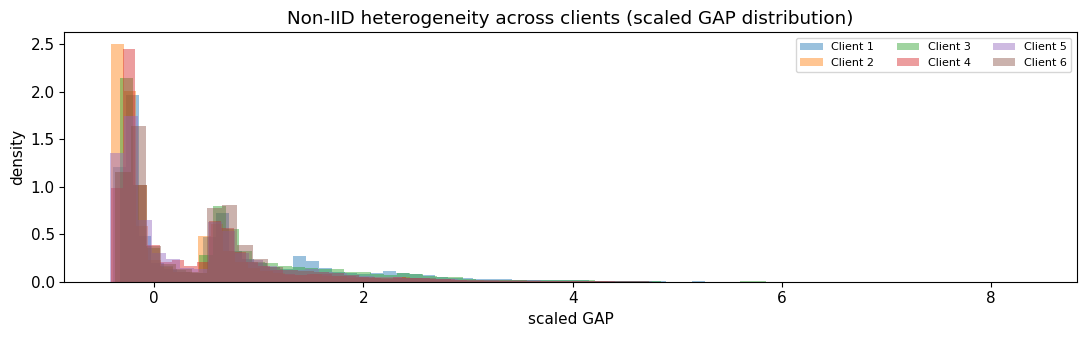

In [3]:
N_CLIENTS = 6
PER_CLIENT = 40_000           # rows per client (subsampled for tractability)

# contiguous temporal blocks -> seasonal heterogeneity (non-IID)
blocks = np.array_split(np.arange(len(X_train)), N_CLIENTS)
clients = []
rng = np.random.default_rng(42)
for b in blocks:
    idx = b if len(b) <= PER_CLIENT else rng.choice(b, PER_CLIENT, replace=False)
    clients.append(X_train[np.sort(idx)])

# quantify heterogeneity via the per-client mean of scaled GAP
gap_means = [c[:, 0].mean() for c in clients]
print('Clients:', [len(c) for c in clients])
print('Mean(scaled GAP) per client:', [round(float(g), 3) for g in gap_means])

fig, ax = plt.subplots(figsize=(11, 3.5))
for i, c in enumerate(clients):
    ax.hist(c[:, 0], bins=60, alpha=0.45, density=True, label=f'Client {i+1}')
ax.set(title='Non-IID heterogeneity across clients (scaled GAP distribution)',
       xlabel='scaled GAP', ylabel='density'); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'federated_noniid_clients.png'), dpi=130); plt.show()

## 3. Centralized baseline (reference)

We train a Dense-AE on **all** the clients' data pooled together. This is the
utility ceiling — the reference against which we measure what is lost by moving
to a federated and/or private setting.

In [4]:
X_central = np.concatenate(clients, axis=0)
print('Centralized:', X_central.shape)
central = C.build_dense_ae(n_features, bottleneck=4)
t0 = time.time()
central.fit(X_central, X_central, epochs=8, batch_size=512, verbose=0)
print(f'Trained in {time.time()-t0:.1f}s')
m_central = full_eval(central, 'centralized')

Centralized: (240000, 17)


2026-06-18 15:57:17.662068: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-18 15:57:17.662117: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 15:57:17.662133: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781791037.662145 1436388 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781791037.662170 1436388 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-18 15:57:18.156097: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Trained in 36.8s
  [centralized           ] F1=0.8107  AUC-PR=0.8274  P=0.835  R=0.787


## 4. Federated Averaging (FedAvg)

Algorithm (McMahan, 2017): in each communication round $t$, every client $k$
starts from the global weights $w_t$, trains for $E$ local epochs and returns
$w_t^k$; the server then aggregates $w_{t+1} = \sum_k \frac{n_k}{n}\, w_t^k$ (a
mean weighted by the number of samples per client). The raw data **never**
leaves the client.

In [5]:
def clone_weights(model):
    return [w.copy() for w in model.get_weights()]

def fedavg(clients, rounds=15, local_epochs=1, batch=256, lr=5e-4):
    global_model = C.build_dense_ae(n_features, bottleneck=4, lr=lr)
    sizes = np.array([len(c) for c in clients], float); sizes /= sizes.sum()
    local = C.build_dense_ae(n_features, bottleneck=4, lr=lr)
    history = []
    for r in range(rounds):
        gw = global_model.get_weights()
        agg = [np.zeros_like(w) for w in gw]
        for k, Xc in enumerate(clients):
            local.set_weights(gw)
            local.fit(Xc, Xc, epochs=local_epochs, batch_size=batch, verbose=0)
            for j, w in enumerate(local.get_weights()):
                agg[j] += sizes[k] * w
        global_model.set_weights(agg)
        if (r + 1) % 3 == 0 or r == 0:
            sv = score(global_model, X_val)
            history.append((r + 1, C.calibrate_threshold(y_val, sv)[1]))
            print(f'  round {r+1:2d}/{rounds}  F1*(val)={history[-1][1]:.4f}')
    return global_model, history

t0 = time.time()
fed_model, fed_hist = fedavg(clients, rounds=15, local_epochs=1)
print(f'FedAvg in {time.time()-t0:.1f}s')
m_fed = full_eval(fed_model, 'federated (FedAvg)')

  round  1/15  F1*(val)=0.7250
  round  3/15  F1*(val)=0.8133
  round  6/15  F1*(val)=0.8232
  round  9/15  F1*(val)=0.8159
  round 12/15  F1*(val)=0.8108
  round 15/15  F1*(val)=0.8073
FedAvg in 145.0s
  [federated (FedAvg)    ] F1=0.8116  AUC-PR=0.8319  P=0.824  R=0.800


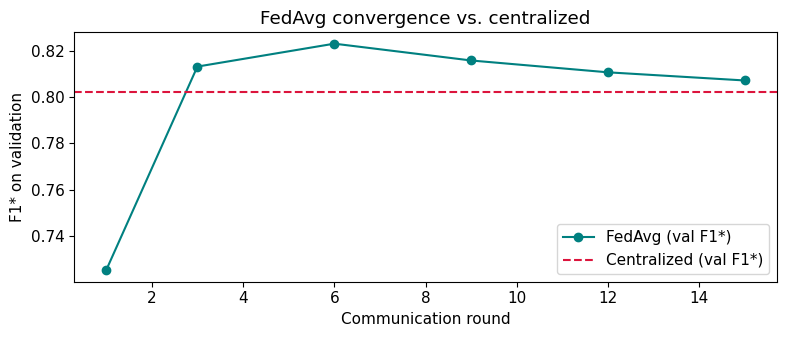

In [6]:
rr, ff = zip(*fed_hist)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(rr, ff, 'o-', color='teal', label='FedAvg (val F1*)')
ax.axhline(C.calibrate_threshold(y_val, score(central, X_val))[1], color='crimson',
           ls='--', label='Centralized (val F1*)')
ax.set(xlabel='Communication round', ylabel='F1* on validation',
       title='FedAvg convergence vs. centralized'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'federated_convergence.png'), dpi=130); plt.show()

## 5. Differential Privacy: RDP accounting

Even though FedAvg never shares raw data, the *weights* themselves can leak
information (e.g. membership inference attacks). **DP-SGD** mitigates this: each
per-example gradient is clipped to norm $C$ and Gaussian noise
$\mathcal N(0,(\sigma C)^2)$ is added.

Accounting follows the **Renyi Differential Privacy** of the *Sampled Gaussian
Mechanism* (Mironov et al., 2019): for sampling rate $q$, noise multiplier
$\sigma$ and integer order $\alpha$,
$$\varepsilon_{\text{RDP}}(\alpha)=\frac{1}{\alpha-1}\log\sum_{k=0}^{\alpha}\binom{\alpha}{k}(1-q)^{\alpha-k}q^{k}\,e^{\frac{k^2-k}{2\sigma^2}},$$
which composes additively over $T$ steps and converts to $(\varepsilon,\delta)$
via $\varepsilon=\min_\alpha\big[T\,\varepsilon_{\text{RDP}}(\alpha)+\frac{\log(1/\delta)}{\alpha-1}\big]$.

In [7]:
def rdp_step(q, sigma, alpha):
    ks = np.arange(alpha + 1)
    log_terms = (gammaln(alpha + 1) - gammaln(ks + 1) - gammaln(alpha - ks + 1)
                 + (alpha - ks) * np.log(1 - q + 1e-12) + ks * np.log(q + 1e-12)
                 + (ks ** 2 - ks) / (2 * sigma ** 2))
    return logsumexp(log_terms) / (alpha - 1)

def compute_epsilon(q, sigma, steps, delta=1e-5):
    orders = list(range(2, 64))
    eps = [steps * rdp_step(q, sigma, a) + np.log(1 / delta) / (a - 1) for a in orders]
    i = int(np.argmin(eps))
    return float(eps[i]), orders[i]

# sanity check: a larger noise multiplier should yield a smaller epsilon
for s in [0.6, 1.0, 2.0]:
    e, a = compute_epsilon(0.04, s, 125)
    print(f'  sigma={s:.1f}  ->  epsilon={e:.2f}  (optimal RDP order alpha={a})')

  sigma=0.6  ->  epsilon=14.49  (optimal RDP order alpha=2)
  sigma=1.0  ->  epsilon=4.19  (optimal RDP order alpha=5)
  sigma=2.0  ->  epsilon=1.32  (optimal RDP order alpha=17)


## 6. DP-SGD training and the privacy-utility trade-off

A self-contained, from-scratch implementation of DP-SGD (per-example gradient
clipping plus noise), run on a subsample of the pooled client data to keep the
cost tractable. We sweep several noise multipliers $\sigma$ and report the
resulting **utility (F1/AUC-PR) vs. privacy $(\varepsilon)$** curve. More noise
means stronger privacy (smaller $\varepsilon$) at the cost of lower utility.

In [8]:
N_DP = 5000
BATCH_DP = 250
EPOCHS_DP = 6
CLIP = 1.0
Xdp = X_central[rng.choice(len(X_central), N_DP, replace=False)].astype('float32')
q = BATCH_DP / N_DP
steps = EPOCHS_DP * (N_DP // BATCH_DP)
print(f'DP-SGD: N={N_DP}, q={q:.3f}, steps={steps}, clip C={CLIP}')

def train_dpsgd(sigma):
    tf.random.set_seed(7)
    model = C.build_dense_ae(n_features, bottleneck=4)
    opt = keras.optimizers.SGD(learning_rate=0.05)
    var = model.trainable_variables
    @tf.function(reduce_retracing=True)
    def dp_step(xb, noise_std):
        def per_example(x):
            x = tf.expand_dims(x, 0)
            with tf.GradientTape() as tape:
                rec = model(x, training=True)
                loss = tf.reduce_mean(tf.square(rec - x))
            g = tape.gradient(loss, var)
            # clip the per-example gradient to global L2 norm CLIP
            flat = tf.concat([tf.reshape(t, [-1]) for t in g], 0)
            factor = tf.minimum(1.0, CLIP / (tf.norm(flat) + 1e-12))
            return [t * factor for t in g]
        per = tf.vectorized_map(per_example, xb)             # per-example gradients (vectorized)
        summed = [tf.reduce_sum(p, axis=0) for p in per]      # sum the clipped gradients over the batch
        bsz = tf.cast(tf.shape(xb)[0], tf.float32)
        # add Gaussian noise to the summed gradient, then average over the batch
        noisy = [(s + tf.random.normal(tf.shape(s), stddev=noise_std)) / bsz for s in summed]
        opt.apply_gradients(zip(noisy, var))
    ns = tf.constant(sigma * CLIP, tf.float32)               # noise std = noise multiplier x clip norm
    for ep in range(EPOCHS_DP):
        perm = rng.permutation(N_DP)
        for s in range(N_DP // BATCH_DP):
            dp_step(tf.constant(Xdp[perm[s*BATCH_DP:(s+1)*BATCH_DP]]), ns)
    return model

dp_rows = []
for sigma in [0.6, 1.0, 1.5, 2.5]:
    t0 = time.time()
    mdl = train_dpsgd(sigma)
    eps, _ = compute_epsilon(q, sigma, steps)
    m = full_eval(mdl, f'DP sigma={sigma}')
    dp_rows.append({'sigma': sigma, 'epsilon': round(eps, 2),
                    'f1': m['f1'], 'auc_pr': m['auc_pr'],
                    'precision': m['precision'], 'recall': m['recall']})
    print(f'    sigma={sigma} -> eps={eps:.2f}  ({time.time()-t0:.0f}s)')
dp_df = pd.DataFrame(dp_rows).sort_values('epsilon')
dp_df

DP-SGD: N=5000, q=0.050, steps=120, clip C=1.0
  [DP sigma=0.6          ] F1=0.7340  AUC-PR=0.5228  P=0.691  R=0.782
    sigma=0.6 -> eps=15.95  (4s)
  [DP sigma=1.0          ] F1=0.7288  AUC-PR=0.5430  P=0.697  R=0.764
    sigma=1.0 -> eps=5.11  (2s)
  [DP sigma=1.5          ] F1=0.7476  AUC-PR=0.5408  P=0.715  R=0.783
    sigma=1.5 -> eps=2.44  (2s)
  [DP sigma=2.5          ] F1=0.7256  AUC-PR=0.5614  P=0.696  R=0.758
    sigma=2.5 -> eps=1.23  (2s)


,sigma,epsilon,f1,auc_pr,precision,recall
3,2.5,1.23,0.725564,0.561417,0.695899,0.757871
2,1.5,2.44,0.747565,0.540838,0.715237,0.782954
1,1.0,5.11,0.728840,0.542961,0.696531,0.764292
0,0.6,15.95,0.733964,0.522812,0.691291,0.782251


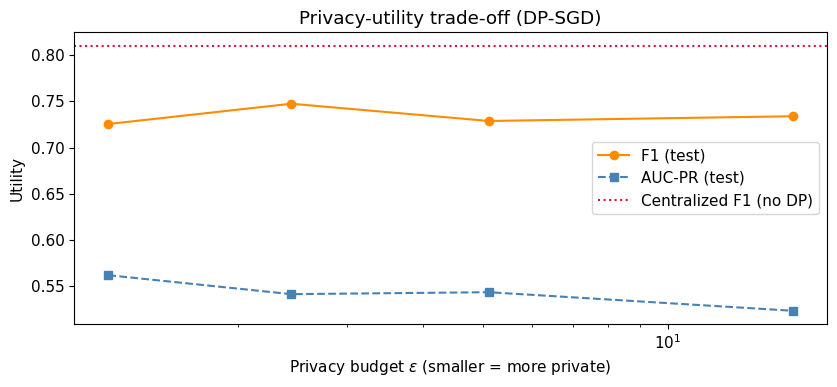

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(dp_df['epsilon'], dp_df['f1'], 'o-', color='darkorange', label='F1 (test)')
ax.plot(dp_df['epsilon'], dp_df['auc_pr'], 's--', color='steelblue', label='AUC-PR (test)')
ax.axhline(m_central['f1'], color='crimson', ls=':', label='Centralized F1 (no DP)')
ax.set(xlabel=r'Privacy budget $\varepsilon$ (smaller = more private)',
       ylabel='Utility', title='Privacy-utility trade-off (DP-SGD)')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'dp_privacy_utility.png'), dpi=130); plt.show()

## 7. Results and saving

In [10]:
summary = pd.DataFrame([
    {'model': 'Centralized', 'f1': m_central['f1'], 'auc_pr': m_central['auc_pr'],
     'precision': m_central['precision'], 'recall': m_central['recall'], 'privacy': 'none'},
    {'model': 'Federated (FedAvg)', 'f1': m_fed['f1'], 'auc_pr': m_fed['auc_pr'],
     'precision': m_fed['precision'], 'recall': m_fed['recall'], 'privacy': 'data not centralized'},
] + [{'model': f"Federated+DP (eps={r['epsilon']})", 'f1': r['f1'], 'auc_pr': r['auc_pr'],
      'precision': r['precision'], 'recall': r['recall'],
      'privacy': f"DP ({r['epsilon']},1e-5)"} for r in dp_rows])
print(summary.to_string(index=False))

dp_df.to_csv(os.path.join(C.DATA_DIR, 'metrics_dp_tradeoff.csv'), index=False)
out = {
    'centralized': {k: m_central[k] for k in ['f1','f2','precision','recall','auc_roc','auc_pr']},
    'federated':   {k: m_fed[k]     for k in ['f1','f2','precision','recall','auc_roc','auc_pr']},
    'fedavg_rounds': 15, 'n_clients': N_CLIENTS, 'noniid': 'temporal_blocks',
    'dp_sgd': dp_rows, 'dp_delta': 1e-5, 'dp_clip': CLIP,
    'utility_cost_federated_f1': round(m_central['f1'] - m_fed['f1'], 4),
    'notes': 'Manual FedAvg + manual DP-SGD with RDP accounting (Mironov 2019).',
}
C.save_metrics('federated', out)
print('\nSaved: metrics_federated.json, metrics_dp_tradeoff.csv,',
      'federated_noniid_clients.png, federated_convergence.png, dp_privacy_utility.png')

                   model       f1   auc_pr  precision   recall              privacy
             Centralized 0.810677 0.827437   0.835372 0.787400                 none
      Federated (FedAvg) 0.811647 0.831932   0.823733 0.799911 data not centralized
Federated+DP (eps=15.95) 0.733964 0.522812   0.691291 0.782251      DP (15.95,1e-5)
 Federated+DP (eps=5.11) 0.728840 0.542961   0.696531 0.764292       DP (5.11,1e-5)
 Federated+DP (eps=2.44) 0.747565 0.540838   0.715237 0.782954       DP (2.44,1e-5)
 Federated+DP (eps=1.23) 0.725564 0.561417   0.695899 0.757871       DP (1.23,1e-5)

Saved: metrics_federated.json, metrics_dp_tradeoff.csv, federated_noniid_clients.png, federated_convergence.png, dp_privacy_utility.png


## 8. Conclusions

- **FedAvg** attains a utility close to the centralized baseline **without
  moving the raw data** off the household; the drop in F1 quantifies the price
  of architectural privacy (see `utility_cost_federated_f1`). This realizes
  GDPR *minimization by design* (Art. 5/25) at the scale of millions of meters.
- **DP-SGD** adds a *formal* $(\varepsilon,\delta)$ guarantee against membership
  inference attacks. The privacy-utility curve makes the trade-off explicit: a
  small $\varepsilon$ (stronger privacy) degrades recall, and the operator picks
  the operating point according to its risk appetite, just as in the cost
  recalibration of NB11.
- **Edge:** the deployed model is the same Dense-AE (~40 KB, <1 ms/sample); the
  federated/DP overhead is incurred only at *training* time, not at *inference*
  time, so the detector remains edge-viable (quantified in NB19).

> **On $\varepsilon$:** the accounting uses the integer-order RDP bound for the
> subsampled Gaussian mechanism (Mironov, 2019), which is a *conservative upper
> bound* (TF-Privacy/Opacus would report somewhat tighter values), so the actual
> privacy is at least as strong as the figures shown here.
>
> **Honest limitation:** the non-IID heterogeneity is simulated through temporal
> blocks of a single dwelling; a real deployment would draw on multiple
> households (e.g. UK-DALE from NB13). The DP sweep is illustrative (a subsample
> of 5,000); at full scale, $\varepsilon$ shrinks for the same $\sigma$.